# Single-frame Object Replace (GroundingDINO + SAM2 + Quantized FLUX Fill)

Ноутбук self-contained и рассчитан на Colab/CUDA.

Что исправлено:
- убраны конфликтующие install-ячейки;
- зафиксирована совместимая версия `transformers==4.47.1` для `groundingdino-py`;
- SAM2 загружается через `SAM2ImagePredictor.from_pretrained(...)`;
- FLUX Fill грузится в квантизованном режиме (4-bit с fallback на 8-bit);
- вызов pipeline адаптивный к сигнатуре (чтобы не падать на `negative_prompt`);
- добавлены memory-оптимизации и ограничение размера ROI.


In [ ]:
# @title 0) Install (run once), then Runtime -> Restart runtime

#%pip -q install -U pip setuptools wheel
#%pip -q install -U   diffusers==0.35.1   transformers==4.47.1   accelerate>=0.34,<1   safetensors>=0.4.3   huggingface_hub>=0.26,<1   groundingdino-py==0.4.0   opencv-python   matplotlib   scipy   bitsandbytes

#%pip -q install -U git+https://github.com/facebookresearch/sam2.git


In [ ]:
#!pip uninstall torch torchvision torchaudio
#!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu128

In [ ]:

#!pip install python-dotenv
#!pip install hf_transfer
#!pip install -U bitsandbytes
#!pip install protobuf
#!pip install sentencepiece
#!pip install accelerate

In [1]:
# @title 1) Imports + runtime config
import os
import inspect
from pathlib import Path
from dotenv import load_dotenv

load_dotenv()

os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"
os.environ["HF_HUB_ENABLE_HF_TRANSFER"] = "1"
os.environ["HF_HUB_DISABLE_XET"] = "1"

import cv2
import numpy as np
import torch
import matplotlib.pyplot as plt
import requests
from PIL import Image

import diffusers
import transformers
import huggingface_hub

from huggingface_hub import login, hf_hub_download
from huggingface_hub.utils import HfHubHTTPError

from diffusers import FluxFillPipeline, FluxTransformer2DModel
from diffusers import BitsAndBytesConfig as DiffusersBitsAndBytesConfig
from diffusers.quantizers import PipelineQuantizationConfig

from transformers import T5EncoderModel
from transformers import BitsAndBytesConfig as TransformersBitsAndBytesConfig

from groundingdino.util.inference import load_model, predict
from sam2.sam2_image_predictor import SAM2ImagePredictor

import torchvision.transforms as T


def pick_device():
    if torch.cuda.is_available():
        return "cuda"
    if hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
        return "mps"
    return "cpu"

DEVICE = pick_device()
DTYPE = torch.bfloat16 if DEVICE == "cuda" else torch.float32

print("torch:", torch.__version__)
print("diffusers:", diffusers.__version__)
print("transformers:", transformers.__version__)
print("huggingface_hub:", huggingface_hub.__version__)
print("device:", DEVICE, "| dtype:", DTYPE)
if DEVICE == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

major_minor = tuple(int(x) for x in transformers.__version__.split(".")[:2])
assert major_minor < (4, 48), "Need transformers<4.48 for groundingdino-py. Re-run install cell and restart runtime."


torch: 2.10.0+cu128
diffusers: 0.36.0
transformers: 4.47.1
huggingface_hub: 0.36.2
device: cuda | dtype: torch.bfloat16
GPU: NVIDIA GeForce RTX 5060


G:\miniconda3\envs\venv\lib\site-packages\timm\models\layers\__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


In [2]:
# @title 2) Hugging Face auth (required for gated FLUX Fill model)
# Put your HF token (Read access). Also accept model license on model page.
HF_TOKEN = os.getenv("HF_TOKEN") # @param {type:"string"}

if HF_TOKEN.strip():
    login(token=HF_TOKEN.strip(), add_to_git_credential=False)
    print("HF login done")
else:
    print("HF_TOKEN is empty. If you get 401 for FLUX model, set token here.")


Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


HF login done


In [3]:
# @title 3) User settings
IMAGE_PATH = "videos/frame.png"  # @param {type:"string"}

OLD_OBJECT_PROMPT = "clock watch"  # @param {type:"string"}
NEW_OBJECT_PROMPT = "a realistic white ceramic coffee mug"  # @param {type:"string"}
NEGATIVE_PROMPT = "blurry, low quality, deformed, duplicated object, artifacts"  # @param {type:"string"}

# Must be FLUX Fill model for inpainting/fill task
FLUX_FILL_MODEL_ID = "black-forest-labs/FLUX.1-Fill-dev"  # @param {type:"string"}

TRY_4BIT_FIRST = False  # @param {type:"boolean"}
USE_CPU_OFFLOAD = True  # @param {type:"boolean"}

BOX_THRESHOLD = 0.82  # @param {type:"number"}
TEXT_THRESHOLD = 0.77  # @param {type:"number"}
ROI_PADDING = 48  # @param {type:"integer"}
MASK_DILATE = 9  # @param {type:"integer"}
MASK_FEATHER = 11  # @param {type:"integer"}
NUM_STEPS = 20  # @param {type:"integer"}
GUIDANCE_SCALE = 6.0  # @param {type:"number"}
SEED = 42  # @param {type:"integer"}
MAX_ROI_SIDE = 1024  # @param {type:"integer"}

GEN_AI_API = "sk-CoYciF7amUAe4VUMv0NkRezxssBY71pIkBr4QoZwzqSWFpuyPG00Bifckml7"


OUT_DIR = "videos/"  # @param {type:"string"}

assert Path(IMAGE_PATH).exists(), f"Image not found: {IMAGE_PATH}"
Path(OUT_DIR).mkdir(parents=True, exist_ok=True)


In [ ]:
# @title 4) Utility functions

def show_image(img, title="", figsize=(7, 7), cmap=None):
    plt.figure(figsize=figsize)
    plt.imshow(img, cmap=cmap)
    plt.title(title)
    plt.axis("off")
    plt.show()


def preprocess_for_gdino(image_np):
    tr = T.Compose([
        T.Resize((800, 800)),
        T.ToTensor(),
        T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
    ])
    return tr(Image.fromarray(image_np))


def detect_best_bbox(gdino_model, image_np, text_prompt, box_thr=0.3, text_thr=0.25, device="cpu"):
    h, w = image_np.shape[:2]
    image_tensor = preprocess_for_gdino(image_np)

    boxes, logits, phrases = predict(
        model=gdino_model,
        image=image_tensor,
        caption=text_prompt,
        box_threshold=box_thr,
        text_threshold=text_thr,
        device=device,
    )
    if len(boxes) == 0:
        return None

    best = int(logits.argmax())
    cx, cy, bw, bh = boxes[best].tolist()
    x1 = max(0, int((cx - bw / 2) * w))
    y1 = max(0, int((cy - bh / 2) * h))
    x2 = min(w, int((cx + bw / 2) * w))
    y2 = min(h, int((cy + bh / 2) * h))
    return (x1, y1, x2, y2), phrases[best], float(logits[best])


def to_mask255(mask):
    m = mask.astype(np.uint8)
    if m.max() <= 1:
        m = m * 255
    return m


def refine_mask(mask, dilate_px=9, feather_px=11):
    hard = to_mask255(mask)
    if dilate_px > 0:
        k = np.ones((dilate_px, dilate_px), np.uint8)
        hard = cv2.dilate(hard, k, iterations=1)

    soft = hard.copy()
    if feather_px > 0:
        ks = feather_px * 2 + 1
        soft = cv2.GaussianBlur(soft, (ks, ks), 0)
    return hard, soft


def mask_bbox(mask255):
    ys, xs = np.where(mask255 > 0)
    if len(xs) == 0:
        return None
    return int(xs.min()), int(ys.min()), int(xs.max()) + 1, int(ys.max()) + 1


def expand_bbox(bbox, w, h, pad=48):
    x1, y1, x2, y2 = bbox
    return max(0, x1 - pad), max(0, y1 - pad), min(w, x2 + pad), min(h, y2 + pad)


def snap_to_multiple(v, base=16, min_v=256):
    return max(min_v, int(np.ceil(v / base) * base))


def clamp_size_keep_aspect(w, h, max_side=896):
    mx = max(w, h)
    if mx <= max_side:
        return w, h
    scale = max_side / float(mx)
    return int(round(w * scale)), int(round(h * scale))


def alpha_insert(base_img, roi_gen, roi_soft_mask, x1, y1, x2, y2):
    out = base_img.copy().astype(np.float32)
    alpha = (roi_soft_mask.astype(np.float32) / 255.0)[..., None]
    src = roi_gen.astype(np.float32)
    dst = out[y1:y2, x1:x2]
    out[y1:y2, x1:x2] = src * alpha + dst * (1.0 - alpha)
    return np.clip(out, 0, 255).astype(np.uint8)


def poisson_insert(base_img, roi_gen, roi_hard_mask, x1, y1, x2, y2):
    src_full = base_img.copy()
    src_full[y1:y2, x1:x2] = roi_gen
    mask_full = np.zeros(base_img.shape[:2], dtype=np.uint8)
    mask_full[y1:y2, x1:x2] = roi_hard_mask

    src_bgr = cv2.cvtColor(src_full, cv2.COLOR_RGB2BGR)
    dst_bgr = cv2.cvtColor(base_img, cv2.COLOR_RGB2BGR)
    center = ((x1 + x2) // 2, (y1 + y2) // 2)
    out_bgr = cv2.seamlessClone(src_bgr, dst_bgr, mask_full, center, cv2.NORMAL_CLONE)
    return cv2.cvtColor(out_bgr, cv2.COLOR_BGR2RGB)


In [5]:
# @title 5) Load GroundingDINO + SAM2
import groundingdino

# GroundingDINO
gdino_ckpt = hf_hub_download(repo_id="ShilongLiu/GroundingDINO", filename="groundingdino_swint_ogc.pth")
gdino_root = Path(groundingdino.__file__).resolve().parent
gdino_cfg = gdino_root / "config" / "GroundingDINO_SwinT_OGC.py"
assert gdino_cfg.exists(), f"GroundingDINO config not found: {gdino_cfg}"

det_seg_device = "cuda" if DEVICE == "cuda" else DEVICE
gdino_model = load_model(str(gdino_cfg), str(gdino_ckpt), device=det_seg_device)
print("GroundingDINO loaded on", det_seg_device)

# SAM2 (no hydra config path issues)
sam2_predictor = SAM2ImagePredictor.from_pretrained("facebook/sam2-hiera-large", device=DEVICE)
print("SAM2 loaded from pretrained")


G:\miniconda3\envs\venv\lib\site-packages\torch\functional.py:505: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\TensorShape.cpp:4383.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


final text_encoder_type: bert-base-uncased
GroundingDINO loaded on cuda


G:\projects\video_changer\src\sam-2\sam2\modeling\position_encoding.py:96: UserWarning: expandable_segments not supported on this platform (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\c10/cuda/CUDAAllocatorConfig.h:39.)
  torch.arange(1, H + 1, dtype=torch.float32, device=device)


SAM2 loaded from pretrained


In [6]:
import gc
import torch


def build_flux_fill_auto(model_id: str, prefer_4bit: bool = True):
    import torch

    has_cuda = torch.cuda.is_available()
    has_mps = torch.backends.mps.is_available()

    if has_cuda:
        device = "cuda"
        dtype = torch.bfloat16
    elif has_mps:
        device = "mps"
        dtype = torch.float32
    else:
        device = "cpu"
        dtype = torch.float32

    print(f"Using device: {device}")

    # ================= CUDA PATH (with quantization) =================
    if has_cuda:
        if prefer_4bit:
            try:
                t5_4bit = TransformersBitsAndBytesConfig(
                    load_in_4bit=True,
                    bnb_4bit_quant_type="nf4",
                    bnb_4bit_use_double_quant=True,
                    bnb_4bit_compute_dtype=dtype
                )

                # 4bit для transformer
                dit_4bit = DiffusersBitsAndBytesConfig(
                    load_in_4bit=True,
                    bnb_4bit_quant_type="nf4",
                    bnb_4bit_use_double_quant=True,
                    bnb_4bit_compute_dtype=dtype
                )

                quant_config = PipelineQuantizationConfig(
                    quant_backend="bitsandbytes_4bit",
                    quant_kwargs={
                        "load_in_4bit": True,
                        "bnb_4bit_quant_type": "nf4",
                        "bnb_4bit_compute_dtype": dtype,
                    },
                    components_to_quantize=["transformer", "text_encoder_2"],
                )

            # --- Загрузка модели ---

                pipe = FluxFillPipeline.from_pretrained(
                    model_id,
                    quantization_config=quant_config,
                    torch_dtype=dtype,
                )

                # --- Оптимизации для 8 GB VRAM ---

                pipe.enable_attention_slicing()
                pipe.vae.enable_slicing()
                #pipe.enable_sequential_cpu_offload()
                pipe.to("cuda")
                return pipe, "4bit_quant"

            except Exception as e:
                print(f"[quant 4bit] failed: {repr(e)}")
                torch.cuda.empty_cache()
                # Падение — откатим квант только для T5

            try:
                # Попробуем только T5 4bit
                t5_only = TransformersBitsAndBytesConfig(
                    load_in_4bit=True,
                    bnb_4bit_quant_type="nf4",
                    bnb_4bit_use_double_quant=True,
                    bnb_4bit_compute_dtype=dtype,
                )

                quant_config = PipelineQuantizationConfig(
                    quant_backend="bitsandbytes_4bit",
                    quant_kwargs={
                        "load_in_4bit": True,
                        "bnb_4bit_quant_type": "nf4",
                        "bnb_4bit_compute_dtype": dtype,
                    },
                    components_to_quantize=["text_encoder_2"],  # Квантуем только text_encoder_2
                )

                pipe = FluxFillPipeline.from_pretrained(
                    model_id,
                    quantization_config=quant_config,
                    torch_dtype=dtype,
                )

                pipe.enable_attention_slicing()
                pipe.vae.enable_slicing()
                #pipe.enable_sequential_cpu_offload()
                pipe.to("cuda")

                print("Loaded FLUX Fill Dev with T5-only 4bit quant")
                return pipe, "t5_4bit_quant"

            except Exception as e2:
                print(f"[t5-only quant] failed: {repr(e2)}")
                torch.cuda.empty_cache()
                print("Falling back to no quantization")

        # если квантование не нужно / не удалось — fallback на без квантования
        print("Loading FLUX Fill Dev without quantization on CUDA...")

        pipe = FluxFillPipeline.from_pretrained(
            model_id,
            torch_dtype=dtype,
        )

        # CPU offload по секвенциям (лучше, чем model_cpu_offload для 8GB)
        pipe.enable_model_cpu_offload()
        pipe.enable_attention_slicing()
        pipe.vae.enable_slicing()
        pipe.enable_vae_tiling()
        #pipe.to("cuda")

        return pipe, "no_quant_cuda"
    
    # ================= CPU / MPS PATH (NO quantization) =================
    print("CUDA not available or prefer_4bit=False. Using CPU/MPS path...")

    pipe = FluxFillPipeline.from_pretrained(
        model_id,
        torch_dtype=dtype,
    )

    if device == "cpu":
        pipe.to("cpu")
    elif device == "mps":
        print("Warning: Flux Fill might be unstable on MPS, falling back to CPU")
        pipe.to("cpu")

    pipe.enable_attention_slicing()
    pipe.vae.enable_slicing()
    pipe.enable_vae_tiling()

    return pipe, "no_quant_cpu"

G:\miniconda3\envs\venv\lib\site-packages\transformers\modeling_utils.py:1113: FutureWarning: The `device` argument is deprecated and will be removed in v5 of Transformers.
  warnings.warn(
G:\miniconda3\envs\venv\lib\site-packages\torch\_dynamo\eval_frame.py:1181: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
G:\miniconda3\envs\venv\lib\site-packages\torch\utils\checkpoint.py:232: UserWarning: None of the inputs have requires_grad=True. Gradients will be None
  check_backward_validity(args)
G:\miniconda3\envs\venv\lib\site-packages\groundingdino\models\GroundingDINO\transformer.py:862: FutureWarning: `torch.cuda.amp.auto

detected: clock watch | conf: 0.8665 | bbox: (292, 134, 424, 210)


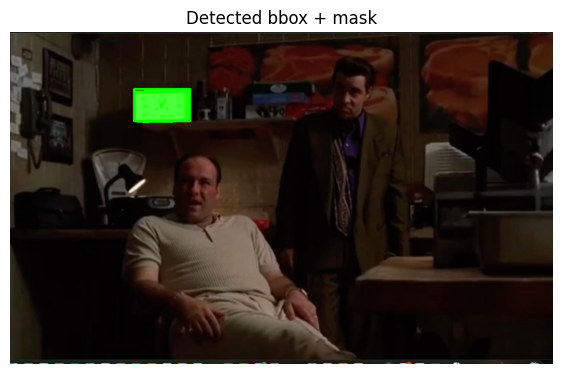

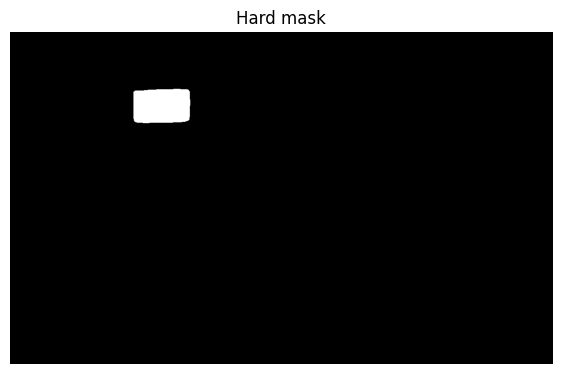

In [7]:
# @title 7) Detect object and get mask
image_np = np.array(Image.open(IMAGE_PATH).convert("RGB"))
h, w = image_np.shape[:2]

det = detect_best_bbox(
    gdino_model,
    image_np,
    OLD_OBJECT_PROMPT,
    box_thr=BOX_THRESHOLD,
    text_thr=TEXT_THRESHOLD,
    device=det_seg_device,
)
if det is None:
    raise RuntimeError("Object not found. Try lower thresholds or another OLD_OBJECT_PROMPT.")

bbox, phrase, conf = det
x1, y1, x2, y2 = bbox
print("detected:", phrase, "| conf:", round(conf, 4), "| bbox:", bbox)

sam2_predictor.set_image(image_np)
masks, scores, _ = sam2_predictor.predict(box=np.array([x1, y1, x2, y2]), multimask_output=True)
best_m = masks[int(np.argmax(scores))].astype(np.uint8) * 255
hard_mask, soft_mask = refine_mask(best_m, dilate_px=MASK_DILATE, feather_px=MASK_FEATHER)

vis = image_np.copy()
cv2.rectangle(vis, (x1, y1), (x2, y2), (0, 255, 0), 3)
overlay = vis.copy()
overlay[..., 1] = np.maximum(overlay[..., 1], hard_mask)
show_image(overlay, "Detected bbox + mask")
show_image(hard_mask, "Hard mask", cmap="gray")


Память очищена.


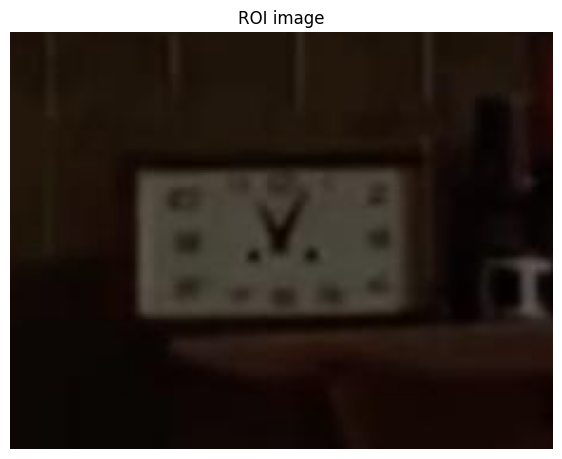

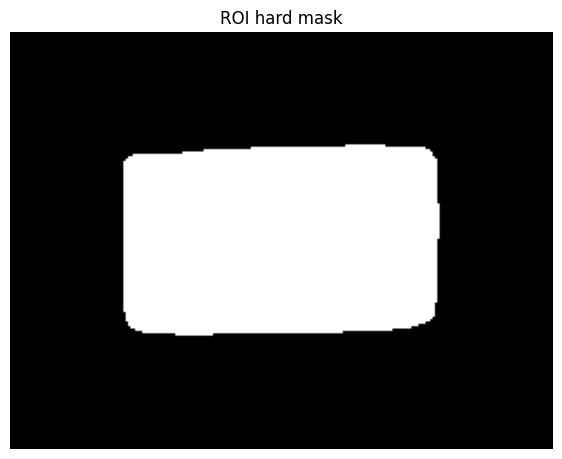

'\ngenerator = torch.Generator(device=pipe.device).manual_seed(SEED)\n\nprint(f"generator device: {generator.device}, pipe device: {pipe.device}")\n\nsig = inspect.signature(pipe.__call__)\nkwargs = {\n    "prompt": prompt,\n    "image": roi_img_pil,\n    "mask_image": roi_mask_pil,\n    "guidance_scale": GUIDANCE_SCALE,\n    "num_inference_steps": NUM_STEPS,\n    "generator": generator,\n    "height": target_h,\n    "width": target_w,\n}\nif "max_sequence_length" in sig.parameters:\n    kwargs["max_sequence_length"] = 512\nif "negative_prompt" in sig.parameters:\n    kwargs["negative_prompt"] = NEGATIVE_PROMPT\nif "true_cfg_scale" in sig.parameters:\n    kwargs["true_cfg_scale"] = max(1.0, GUIDANCE_SCALE / 10.0)\n\ntry:\n    with torch.inference_mode():\n        gen_roi = pipe(**kwargs).images[0]\nexcept torch.cuda.OutOfMemoryError:\n    if DEVICE != "cuda":\n        raise\n    torch.cuda.empty_cache()\n    print("OOM: retry with smaller ROI and fewer steps")\n    small_w = max(256, (

In [ ]:
if 'gdino_model' in dir():
    del gdino_model
if 'sam2_predictor' in dir():
    del sam2_predictor
# Принудительный сбор мусора и очистка кэша CUDA
gc.collect()
torch.cuda.empty_cache()
torch.cuda.synchronize() # Синхронизируем, чтобы убедиться, что память освобождена
print("Память очищена.")

#pipe, quant_mode = build_flux_fill_auto(FLUX_FILL_MODEL_ID, prefer_4bit=TRY_4BIT_FIRST)
#print("FLUX загружен в память")

# @title 8) Generate replacement on ROI only
mb = mask_bbox(hard_mask)
if mb is None:
    raise RuntimeError("Mask is empty after refinement.")

rx1, ry1, rx2, ry2 = expand_bbox(mb, w, h, pad=ROI_PADDING)
roi_img = image_np[ry1:ry2, rx1:rx2]
roi_hard = hard_mask[ry1:ry2, rx1:rx2]
roi_soft = soft_mask[ry1:ry2, rx1:rx2]

show_image(roi_img, "ROI image")
show_image(roi_hard, "ROI hard mask", cmap="gray")

rw, rh = roi_img.shape[1], roi_img.shape[0]
rw, rh = clamp_size_keep_aspect(rw, rh, max_side=MAX_ROI_SIDE)
target_w = snap_to_multiple(rw, base=16, min_v=256)
target_h = snap_to_multiple(rh, base=16, min_v=256)

roi_img_pil = Image.fromarray(roi_img).resize((target_w, target_h), Image.Resampling.LANCZOS)
roi_mask_pil = Image.fromarray(roi_hard).resize((target_w, target_h), Image.Resampling.NEAREST)

prompt = (
    f"Replace {OLD_OBJECT_PROMPT} to a {NEW_OBJECT_PROMPT} new object should be in the mask box. "
    "Photorealistic. Match original scene lighting, perspective, depth of field, color and noise. "
    "Replace only the masked object and keep surroundings consistent. "
    "If new object is smaller, reconstruct background naturally."
)

"""
generator = torch.Generator(device=pipe.device).manual_seed(SEED)

print(f"generator device: {generator.device}, pipe device: {pipe.device}")

sig = inspect.signature(pipe.__call__)
kwargs = {
    "prompt": prompt,
    "image": roi_img_pil,
    "mask_image": roi_mask_pil,
    "guidance_scale": GUIDANCE_SCALE,
    "num_inference_steps": NUM_STEPS,
    "generator": generator,
    "height": target_h,
    "width": target_w,
}
if "max_sequence_length" in sig.parameters:
    kwargs["max_sequence_length"] = 512
if "negative_prompt" in sig.parameters:
    kwargs["negative_prompt"] = NEGATIVE_PROMPT
if "true_cfg_scale" in sig.parameters:
    kwargs["true_cfg_scale"] = max(1.0, GUIDANCE_SCALE / 10.0)

try:
    with torch.inference_mode():
        gen_roi = pipe(**kwargs).images[0]
except torch.cuda.OutOfMemoryError:
    if DEVICE != "cuda":
        raise
    torch.cuda.empty_cache()
    print("OOM: retry with smaller ROI and fewer steps")
    small_w = max(256, (target_w * 3) // 4)
    small_h = max(256, (target_h * 3) // 4)
    small_w = snap_to_multiple(small_w, base=16, min_v=256)
    small_h = snap_to_multiple(small_h, base=16, min_v=256)
    kwargs["image"] = roi_img_pil.resize((small_w, small_h), Image.Resampling.LANCZOS)
    kwargs["mask_image"] = roi_mask_pil.resize((small_w, small_h), Image.Resampling.NEAREST)
    kwargs["width"] = small_w
    kwargs["height"] = small_h
    kwargs["num_inference_steps"] = max(10, NUM_STEPS // 2)
    with torch.inference_mode():
        gen_roi = pipe(**kwargs).images[0]

# back to original ROI size
gen_roi_np = np.array(gen_roi.resize((roi_img.shape[1], roi_img.shape[0]), Image.Resampling.LANCZOS))
show_image(gen_roi_np, f"Generated ROI ({quant_mode})")
"""


In [22]:
prompt

'Replace clock watch to a a realistic white ceramic coffee mug new object should be in the mask box. Photorealistic. Match original scene lighting, perspective, depth of field, color and noise. Replace only the masked object and keep surroundings consistent. If new object is smaller, reconstruct background naturally.'

In [56]:
import base64
import io
import json
import PIL

from io import BytesIO

def pil_to_base64(pil_image, format="JPEG"):
    buffer = BytesIO()
    
    if format.upper() == "JPEG" and pil_image.mode != "RGB":
        pil_image = pil_image.convert("RGB")
    
    pil_image.save(buffer, format=format)
    img_str = base64.b64encode(buffer.getvalue()).decode("utf-8")
    
    return f"data:image/{format.lower()};base64,{img_str}"

# Конвертируем изображения в base64
roi_img_b64 = pil_to_base64(roi_img_pil)
roi_mask_b64 = pil_to_base64(roi_mask_pil)


# Создаем словарь files правильно для множественных файлов
def pil_to_bytes(pil_image, format="JPEG"):
    buffer = BytesIO()
    
    if format.upper() == "JPEG" and pil_image.mode != "RGB":
        pil_image = pil_image.convert("RGB")
    
    pil_image.save(buffer, format=format)
    buffer.seek(0)
    return buffer

files = [
    (
        "image_urls[]",   # <-- ВАЖНО! именно массив
        ("roi_img.jpg", pil_to_bytes(roi_img_pil), "image/jpeg")
    ),
    (
        "image_urls[]",
        ("roi_mask.jpg", pil_to_bytes(roi_mask_pil), "image/jpeg")
    )
]

data = {
    "prompt": prompt,
    "seed": SEED,
    "resolution": "0.5K",
}

headers = {
    'Accept': 'application/json',
    'Authorization': f'Bearer {GEN_AI_API}'
}

url_endpoint = "https://api.gen-api.ru/api/v1/networks/nano-banana-2"

response = requests.post(
    url_endpoint,
    headers=headers,
    data=data,
    files=files
)

In [74]:
response.json()

{'request_id': 40978483, 'model': 'nano-banana-2', 'status': 'processing'}

In [77]:
result_url = f"https://api.gen-api.ru/api/v1/request/get/{response.json()['request_id']}"
result_response = requests.get(result_url, headers=headers)
result_response.json()

{'id': 40978483,
 'network': 'nano-banana-2',
 'status': 'success',
 'response_type': 'image',
 'cost': 15,
 'progress': 100,
 'runtime': 29.71,
 'result': ['https://gen-api.storage.yandexcloud.net/input_files/1772644940_69a86a4c15cb3.webp'],
 'full_response': [{'url': 'https://gen-api.storage.yandexcloud.net/input_files/1772644940_69a86a4c15cb3.webp'}],
 'parameters': {'seed': 42,
  'prompt': 'Replace clock watch to a a realistic white ceramic coffee mug new object should be in the mask box. Photorealistic. Match original scene lighting, perspective, depth of field, color and noise. Replace only the masked object and keep surroundings consistent. If new object is smaller, reconstruct background naturally.',
  'is_sync': False,
  'image_urls': ['https://gen-api.storage.yandexcloud.net/input_files/1772644912_69a86a30c0ff8.jpg',
   'https://gen-api.storage.yandexcloud.net/input_files/1772644912_69a86a30cf17c.jpg'],
  'num_images': 1,
  'resolution': '0.5K',
  'aspect_ratio': '16:9',
  'o

In [80]:
def match_domain(patch, target_roi):
    """
    patch — сгенерированный объект (H,W,3)
    target_roi — оригинальный ROI из кадра
    """

    result = patch.copy().astype(np.float32)
    target = target_roi.astype(np.float32)

    # 1️⃣ Match mean / std (цвет и контраст)
    for c in range(3):
        p_mean, p_std = result[:,:,c].mean(), result[:,:,c].std()
        t_mean, t_std = target[:,:,c].mean(), target[:,:,c].std()

        if p_std > 1e-6:
            result[:,:,c] = (result[:,:,c] - p_mean) / p_std * t_std + t_mean

    # 2️⃣ Добавить шум как в оригинале
    noise = target - cv2.GaussianBlur(target, (7,7), 0)
    noise_std = noise.std()

    synthetic_noise = np.random.normal(0, noise_std, result.shape)
    result += synthetic_noise

    # 3️⃣ Немного размыть (старый кадр мягкий)
    result = cv2.GaussianBlur(result, (5,5), 0)

    # 4️⃣ Лёгкая JPEG-деградация
    encode_param = [int(cv2.IMWRITE_JPEG_QUALITY), 70]
    _, enc = cv2.imencode('.jpg', result.astype(np.uint8), encode_param)
    result = cv2.imdecode(enc, 1)

    return np.clip(result, 0, 255).astype(np.uint8)

gen_url = result_response.json()["result"][0]  # проверь точный ключ!

img_response = requests.get(gen_url)
gen_roi = Image.open(BytesIO(img_response.content)).convert("RGB")

gen_roi_np = np.array(gen_roi)

gen_roi_np = np.array(
    gen_roi.resize(
        (roi_img.shape[1], roi_img.shape[0]),
        Image.Resampling.LANCZOS
    )
)

gen_roi_np = match_domain(
    gen_roi_np,
    image_np[ry1:ry2, rx1:rx2]
)

In [ ]:
"""
# создаём простую тестовую картинку
img = Image.new("RGB", (512, 512), "white")

mask = Image.new("L", (512, 512), 0)
mask_np = np.array(mask)
mask_np[200:350, 200:350] = 255
mask = Image.fromarray(mask_np)

result = pipe(
    prompt="a realistic coffee mug",
    image=img,
    mask_image=mask,
    num_inference_steps=30,
    guidance_scale=7.5,
).images[0]

display(result)
"""

In [88]:
from skimage.exposure import match_histograms


def insert_object_pro(
    base_img,
    roi_gen,
    roi_mask,
    x1, y1, x2, y2
):
    """
    base_img  — оригинальный кадр (RGB)
    roi_gen   — сгенерированная кружка (RGB, уже resize к ROI)
    roi_mask  — hard mask объекта (0/255)
    """

    base = base_img.copy().astype(np.float32)
    target_roi = base[y1:y2, x1:x2].astype(np.float32)
    patch = roi_gen.astype(np.float32)

    # --------------------------------
    # 1️⃣ Histogram matching (цвет + тон)
    # --------------------------------
    patch = match_histograms(
        patch.astype(np.uint8),
        target_roi.astype(np.uint8),
        channel_axis=2
    ).astype(np.float32)

    # --------------------------------
    # 2️⃣ Подгон средней яркости
    # --------------------------------
    mean_src = patch.mean()
    mean_dst = target_roi.mean()
    patch += (mean_dst - mean_src)

    # --------------------------------
    # 3️⃣ Добавление шума как в кадре
    # --------------------------------
    noise = target_roi - cv2.GaussianBlur(target_roi, (7,7), 0)
    noise_std = noise.std()

    synthetic_noise = np.random.normal(0, noise_std, patch.shape)
    patch += synthetic_noise

    # --------------------------------
    # 4️⃣ Смягчение резкости (старый кадр мягкий)
    # --------------------------------
    patch = cv2.GaussianBlur(patch, (5,5), 0)

    # --------------------------------
    # 5️⃣ Правильная мягкая маска
    # --------------------------------
    kernel = np.ones((5,5), np.uint8)
    mask = cv2.erode(roi_mask, kernel, iterations=1)
    mask = cv2.GaussianBlur(mask, (31,31), 0)

    alpha = (mask.astype(np.float32)/255.0)[...,None]

    # --------------------------------
    # 6️⃣ Альфа-композитинг
    # --------------------------------
    blended = patch * alpha + target_roi * (1 - alpha)

    encode_param = [int(cv2.IMWRITE_JPEG_QUALITY), 75]
    _, enc = cv2.imencode('.jpg', blended.astype(np.uint8), encode_param)
    blended = cv2.imdecode(enc, 1).astype(np.float32)

    base[y1:y2, x1:x2] = blended

    return np.clip(base, 0, 255).astype(np.uint8)

In [90]:
final_result = insert_object_pro(
    image_np,
    gen_roi_np,
    roi_hard,
    rx1, ry1, rx2, ry2
)

Image.fromarray(final_result).save("videos/insert_object_pro_result.png")

In [91]:
def alpha_insert_smooth(base_img, roi_gen, roi_mask, x1, y1, x2, y2):
    """
    base_img — оригинал (RGB uint8)
    roi_gen  — сгенерированный объект (RGB uint8, размер ROI)
    roi_mask — hard mask (0/255)
    """

    base = base_img.copy().astype(np.float32)
    target = base[y1:y2, x1:x2].astype(np.float32)
    patch = roi_gen.astype(np.float32)

    # -------------------------------------------------
    # 1️⃣ Локальное выравнивание яркости ТОЛЬКО по краю
    # -------------------------------------------------
    edge_band = cv2.dilate(roi_mask, np.ones((7,7), np.uint8), 1) - roi_mask
    edge_band = edge_band.astype(bool)

    if edge_band.sum() > 0:
        src_edge_mean = patch[edge_band].mean()
        dst_edge_mean = target[edge_band].mean()
        patch += (dst_edge_mean - src_edge_mean)

    # -------------------------------------------------
    # 2️⃣ Подгон шума под фон
    # -------------------------------------------------
    noise = target - cv2.GaussianBlur(target, (7,7), 0)
    noise_std = noise.std()
    patch += np.random.normal(0, noise_std, patch.shape)

    # -------------------------------------------------
    # 3️⃣ Подгон резкости под фон
    # -------------------------------------------------
    target_blur = cv2.Laplacian(target, cv2.CV_32F).var()
    patch_blur = cv2.Laplacian(patch, cv2.CV_32F).var()

    if patch_blur > target_blur:
        patch = cv2.GaussianBlur(patch, (5,5), 0)

    # -------------------------------------------------
    # 4️⃣ Правильная edge-aware маска
    # -------------------------------------------------
    kernel = np.ones((5,5), np.uint8)
    mask = cv2.erode(roi_mask, kernel, iterations=1)
    mask = cv2.GaussianBlur(mask, (41,41), 0)  # большой blur = мягкий градиент

    alpha = (mask.astype(np.float32) / 255.0)[..., None]

    # -------------------------------------------------
    # 5️⃣ Градиентно-смягчённый блендинг
    # -------------------------------------------------
    blended = patch * alpha + target * (1 - alpha)

    base[y1:y2, x1:x2] = blended

    return np.clip(base, 0, 255).astype(np.uint8)

In [92]:
final_aplpha_smooth = alpha_insert_smooth(
    image_np,
    gen_roi_np,
    roi_hard,
    rx1, ry1, rx2, ry2
)

Image.fromarray(final_aplpha_smooth).save("videos/final_aplpha_smooth.png")

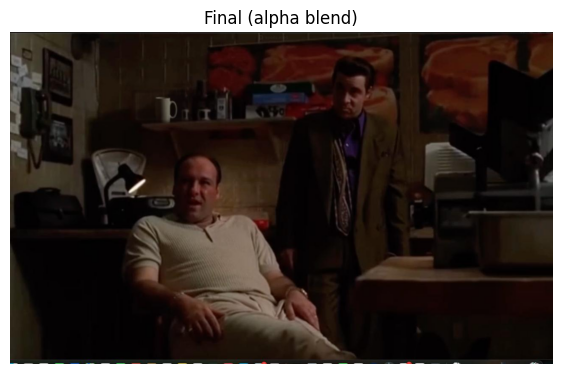

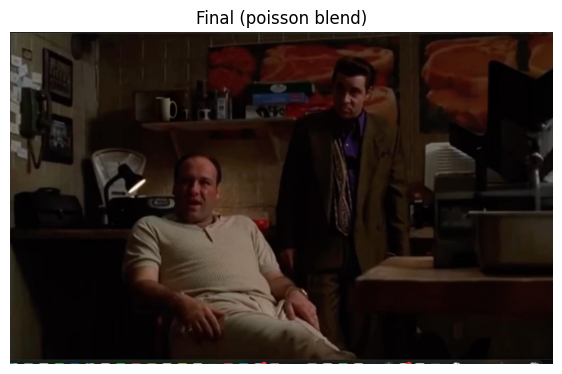

Saved: videos\output_replace_alpha.png
Saved: videos\output_replace_poisson.png


In [87]:
# @title 9) Composite and save
final_alpha = alpha_insert(image_np, gen_roi_np, roi_soft, rx1, ry1, rx2, ry2)
final_poisson = poisson_insert(image_np, gen_roi_np, roi_hard, rx1, ry1, rx2, ry2)

show_image(final_alpha, "Final (alpha blend)")
show_image(final_poisson, "Final (poisson blend)")

alpha_path = str(Path(OUT_DIR) / "output_replace_alpha.png")
poisson_path = str(Path(OUT_DIR) / "output_replace_poisson.png")
Image.fromarray(final_alpha).save(alpha_path)
Image.fromarray(final_poisson).save(poisson_path)
print("Saved:", alpha_path)
print("Saved:", poisson_path)


## Notes
- Если получаете `401` при загрузке FLUX модели: примите лицензию модели на Hugging Face и задайте `HF_TOKEN`.
- Если OOM сохраняется: уменьшите `MAX_ROI_SIDE` до `768`, `NUM_STEPS` до `12`, `GUIDANCE_SCALE` до `10`.
- Для сложной детекции снизьте `BOX_THRESHOLD/TEXT_THRESHOLD`.
